# MSI 训练数据敏感性分析

读取已完成实验；不会重新训练。请使用项目的 Python 环境。

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image, Markdown
root = Path.cwd()
if not (root / 'run_experiment.py').exists():
    root = root.parent
results = root / 'results/full'
assert (results / 'completion.json').exists()

## 协议与条件限制

142条训练池，36条固定评估；训练量[36, 71, 107]，重复30次，背景20条；100%仅为参考。区间表示条件抽样波动。

In [2]:
stability = pd.read_csv(results / 'stability.csv')
family = pd.read_csv(results / 'family.csv')
features = pd.read_csv(results / 'feature_summary.csv')
performance = pd.read_csv(results / 'performance.csv')
display(stability.groupby(['size', 'model', 'method']).rho_reference.agg(['median', 'min', 'max']))

median       min       max
size model method                                  
36   GBRT  KernelSHAP  0.520879 -0.230769  0.832967
           PFI         0.556044 -0.050549  0.885714
     LR    KernelSHAP  0.531868  0.050549  0.832967
           PFI         0.481319 -0.054945  0.863736
     RF    KernelSHAP  0.584615  0.182418  0.854945
           PFI         0.723077  0.406593  0.929670
     SVR   KernelSHAP  0.492308 -0.195604  0.903297
           PFI         0.549451  0.054945  0.872527
71   GBRT  KernelSHAP  0.815385  0.626374  0.920879
           PFI         0.687912  0.393407  0.912088
     LR    KernelSHAP  0.764835  0.371429  0.920879
           PFI         0.813187  0.318681  0.960440
     RF    KernelSHAP  0.808791  0.630769  0.934066
           PFI         0.843956  0.441758  0.964835
     SVR   KernelSHAP  0.778022  0.454945  0.925275
           PFI         0.709890  0.397802  0.872527
107  GBRT  KernelSHAP  0.890110  0.670330  0.956044
           PFI         0.751648  0.463736  0.903297
     LR    KernelSHAP  0.912088  0.538462  0.986813
           PFI         0.912088  0.235165  0.991209
     RF    KernelSHAP  0.905495  0.749451  0.960440
           PFI         0.874725  0.709890  0.986813
     SVR   KernelSHAP  0.879121  0.560440  0.986813
           PFI         0.826374  0.595604  0.938462

In [3]:
display(family.groupby('size').delta.agg(['median', 'min', 'max']))
display(features[features.feature == 'surface_energy_M'][['size', 'model', 'method', 'top3_frequency']])

,median,min,max
size,,,
36,0.246886,-0.152015,0.500366
71,0.264469,0.032967,0.472894
107,0.291392,0.104396,0.402564


,size,model,method,top3_frequency
11,107,GBRT,PFI,1.000000
25,107,GBRT,KernelSHAP,1.000000
39,107,LR,PFI,1.000000
53,107,LR,KernelSHAP,1.000000
67,107,RF,PFI,1.000000
81,107,RF,KernelSHAP,1.000000
95,107,SVR,PFI,1.000000
109,107,SVR,KernelSHAP,1.000000
123,36,GBRT,PFI,0.866667
137,36,GBRT,KernelSHAP,0.933333


In [4]:
display(performance.groupby(['size', 'model'])[['mae', 'r2']].median())

mae        r2
size model                    
36   GBRT   0.227158  0.531961
     LR     0.271426  0.370771
     RF     0.227832  0.562816
     SVR    0.196869  0.671830
71   GBRT   0.173659  0.722443
     LR     0.215211  0.615791
     RF     0.189395  0.707567
     SVR    0.164124  0.775111
107  GBRT   0.152271  0.776428
     LR     0.196681  0.668738
     RF     0.164377  0.785119
     SVR    0.144940  0.819616
142  GBRT   0.153110  0.780374
     LR     0.187766  0.704193
     RF     0.162499  0.797687
     SVR    0.138572  0.841178

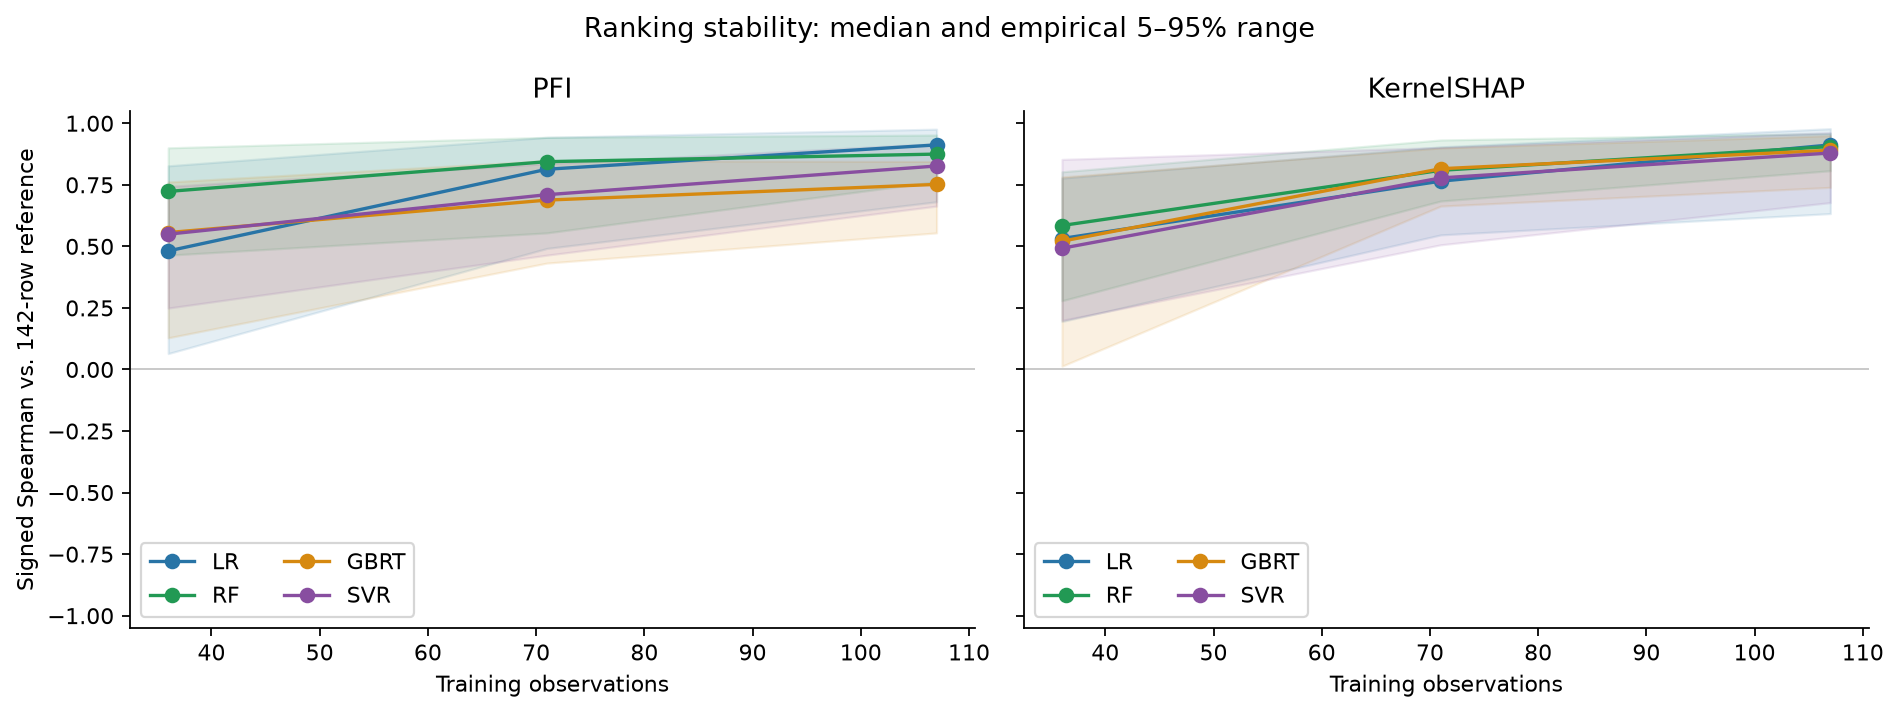

In [5]:
display(Image(filename=str(results / 'figures/stability_curve.png')))

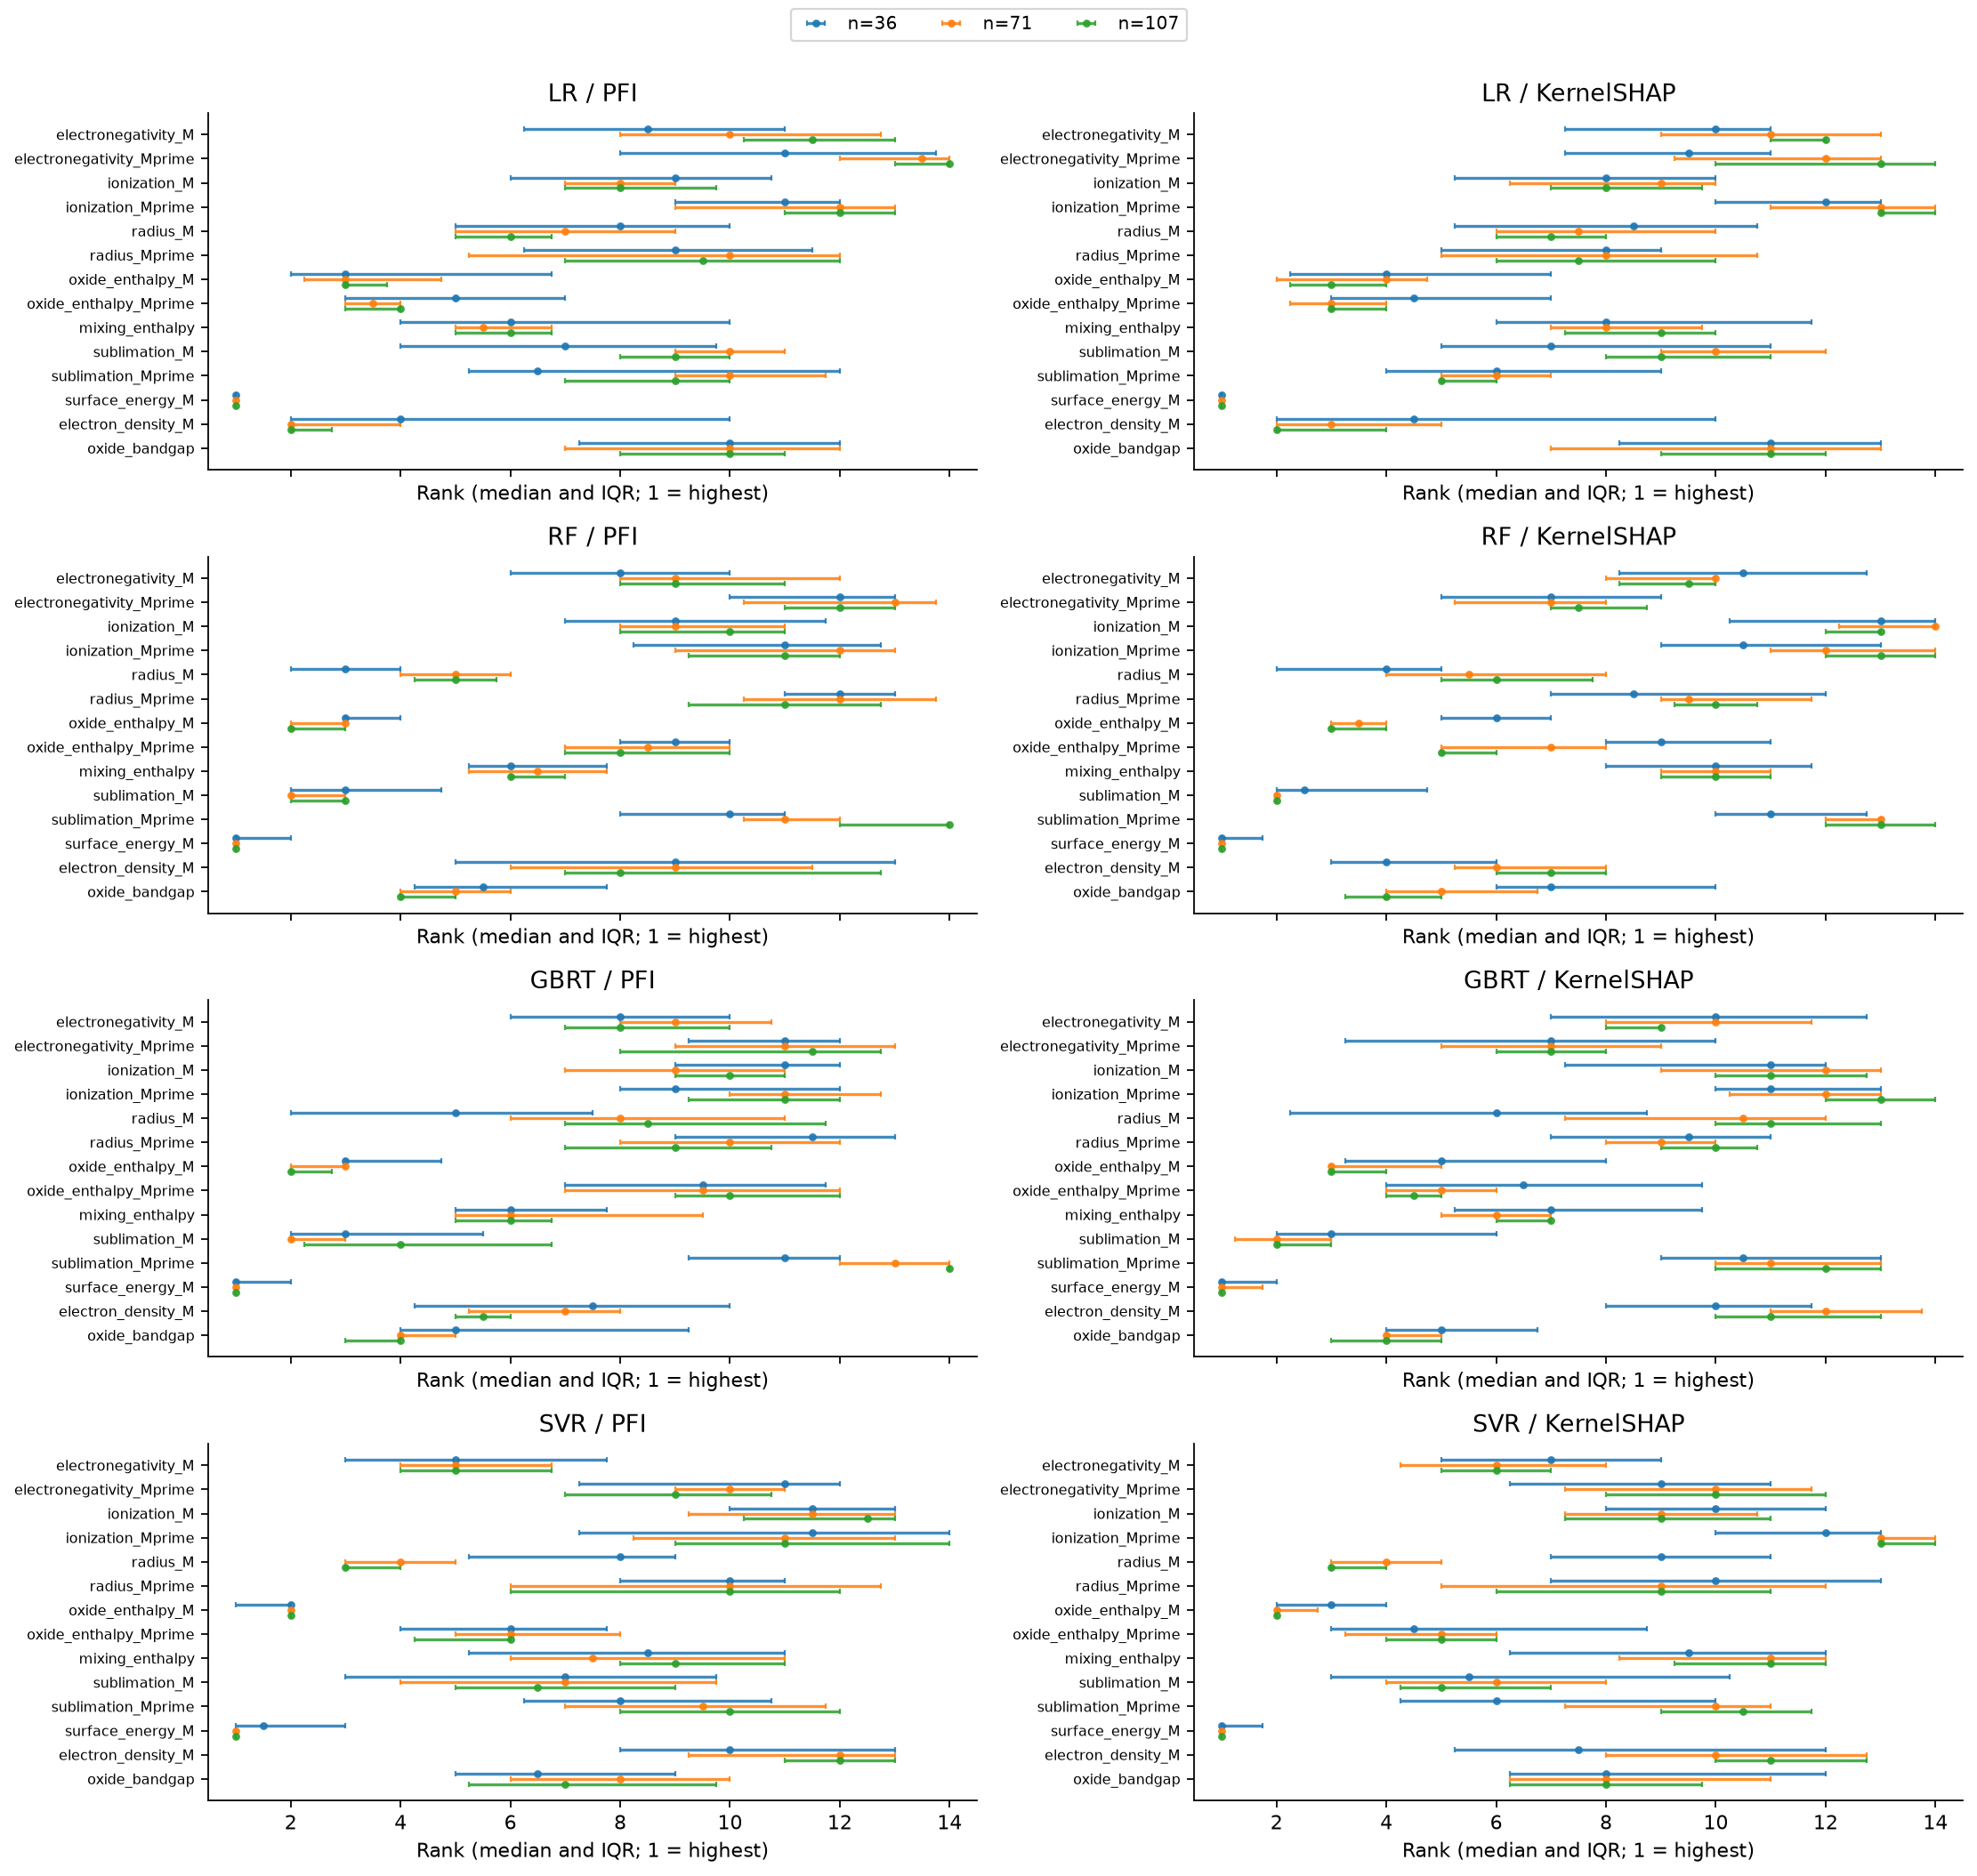

In [6]:
display(Image(filename=str(results / 'figures/rank_distributions.png')))

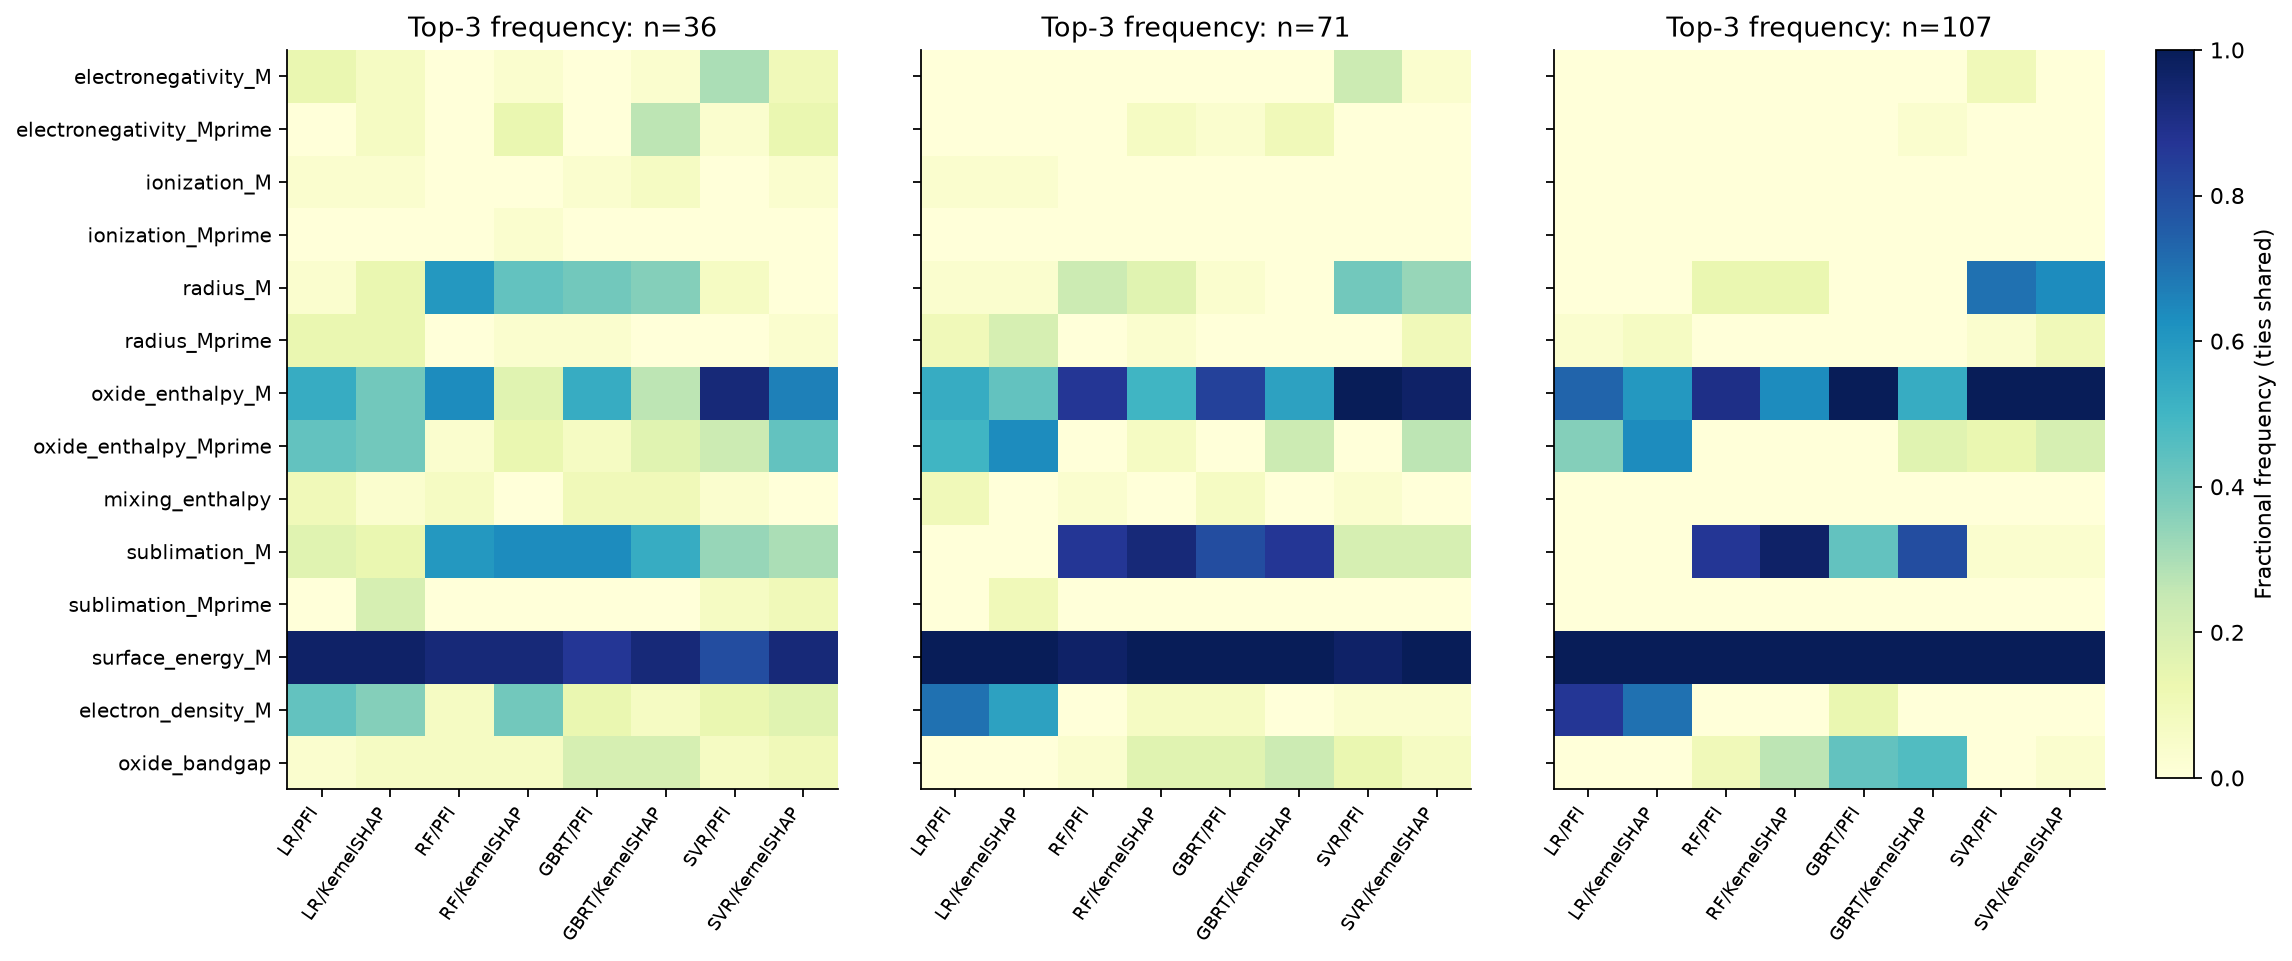

In [7]:
display(Image(filename=str(results / 'figures/top3_frequency.png')))

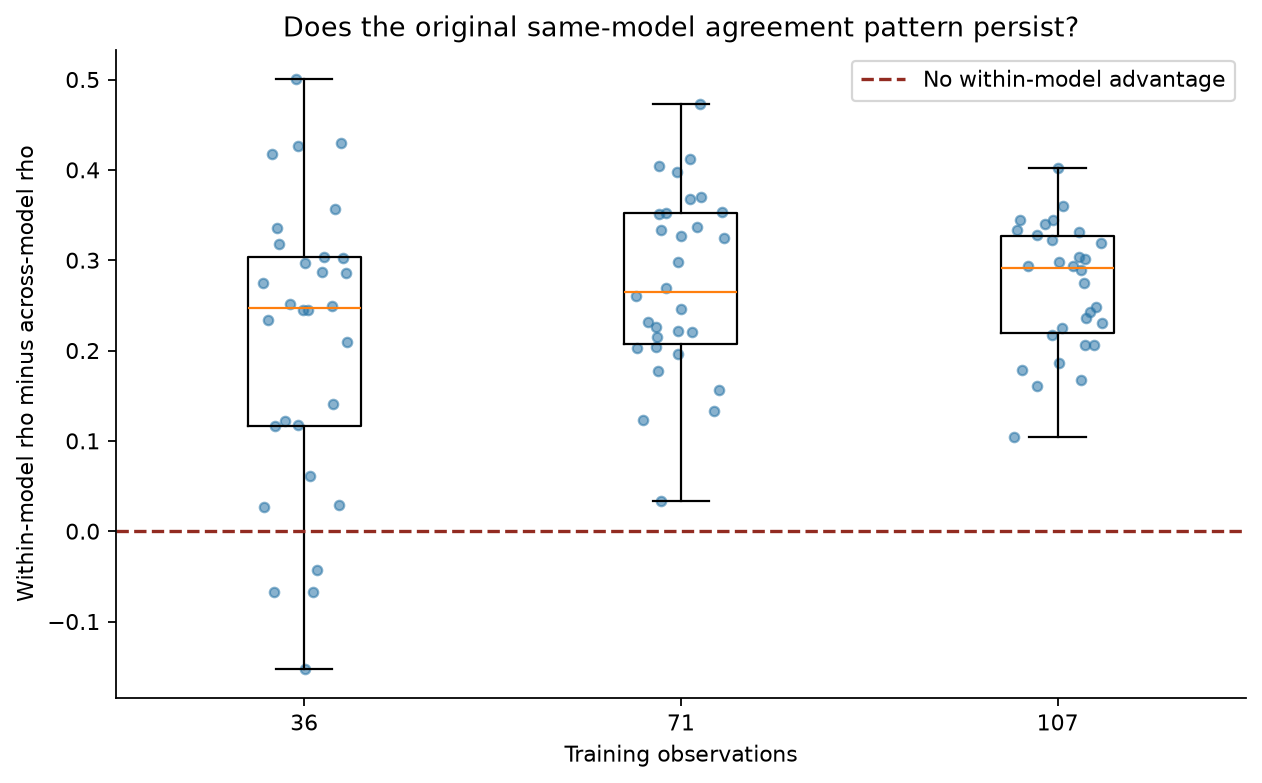

In [8]:
display(Image(filename=str(results / 'figures/family_delta.png')))

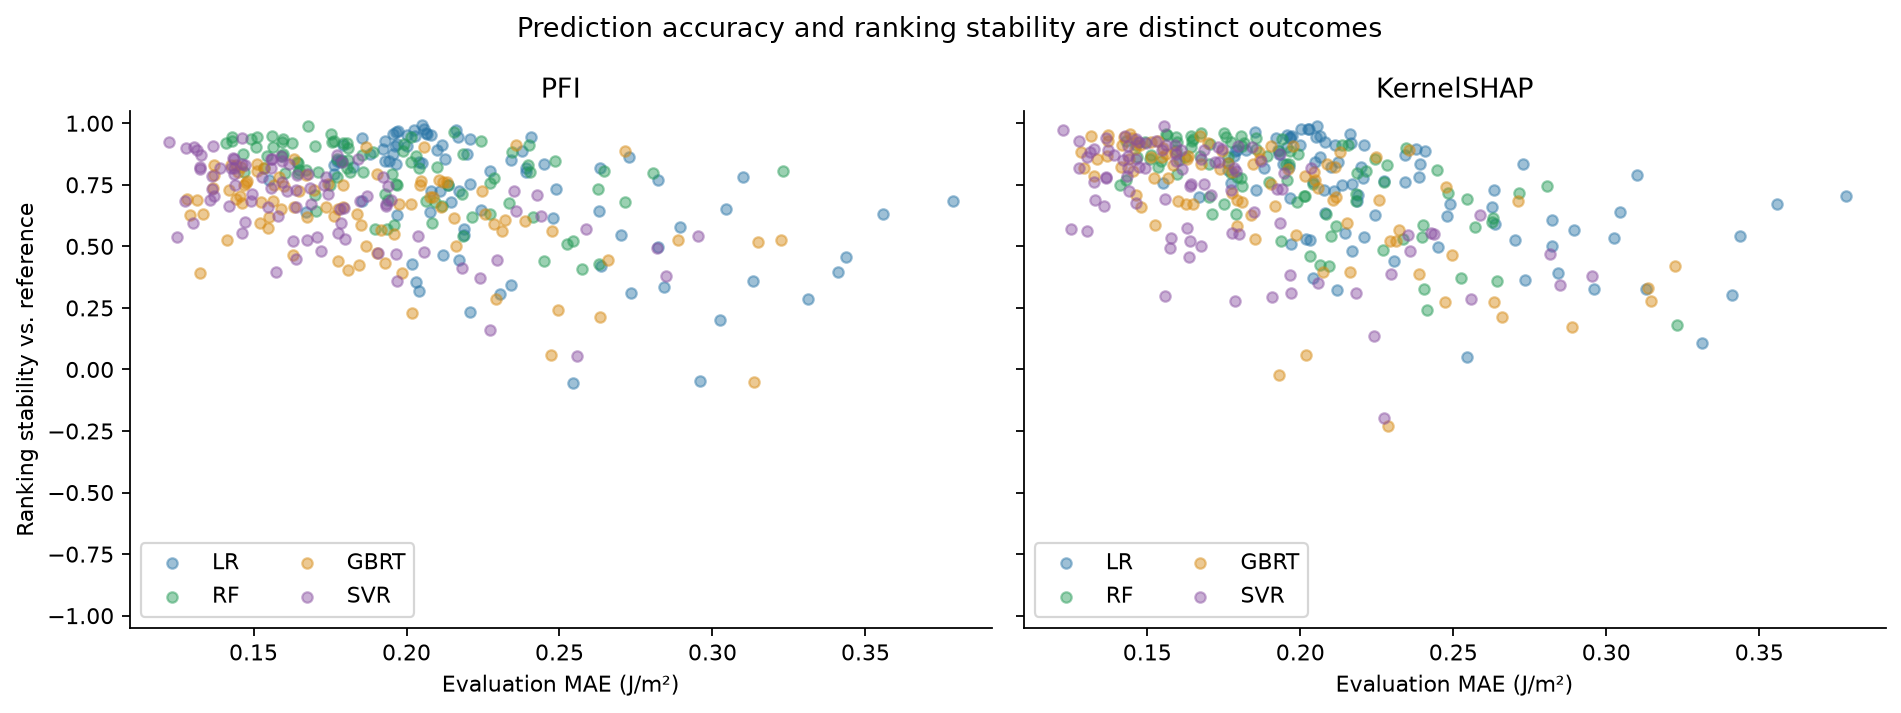

In [9]:
display(Image(filename=str(results / 'figures/accuracy_stability.png')))

In [10]:
report = (results / 'report_zh.md').read_text(encoding='utf-8')
figure_prefix = (results / 'figures').relative_to(root).as_posix()
report = report.replace('](figures/', '](' + figure_prefix + '/')
report = report.replace('](../../README.md)', '](README.md)')
display(Markdown(report))

# 训练数据变化下的特征重要性稳定性：MSI 实验报告

## 实验设置

完成 364 次训练，4个模型 × 两种共同解释方法。训练池142条，固定评估集36条；
抽样设置：36条×30次，71条×30次，107条×30次。KernelSHAP预算为512，背景20条，PFI重复30次。
模型参数来自原仓库并固定；标准化只在当前训练子集拟合。100%模型只作为参考。

## 1. 换训练样本后，排名是否保持？

下表为相对142条参考模型的带符号Spearman中位数。1表示排名相同，负值表示倾向反向。

| 模型 / 方法 | n=36 | n=71 | n=107 |
|---|---:|---:|---:|
| GBRT / KernelSHAP | 0.521 | 0.815 | 0.890 |
| GBRT / PFI | 0.556 | 0.688 | 0.752 |
| LR / KernelSHAP | 0.532 | 0.765 | 0.912 |
| LR / PFI | 0.481 | 0.813 | 0.912 |
| RF / KernelSHAP | 0.585 | 0.809 | 0.905 |
| RF / PFI | 0.723 | 0.844 | 0.875 |
| SVR / KernelSHAP | 0.492 | 0.778 | 0.879 |
| SVR / PFI | 0.549 | 0.710 | 0.826 |

![排名稳定性](results/full/figures/stability_curve.png)

完整特征排名中位数、IQR和5–95%范围见 feature_summary.csv。小样本重复抽样的排名波动描述了对训练样本选择的敏感性。

## 2. “同一模型内解释方法更一致”是否保持？

差值 = 4个模型内部PFI–SHAP相关性的均值 − 两种解释方法各自跨模型6个配对相关性的等权均值。

| 训练样本 | 差值中位数 | 经验5–95%范围 | 差值为正的比例 | 判断 |
|---|---:|---|---:|---|
| 36 | 0.247 | [-0.067, 0.428] | 86.7% | 结论依赖训练样本，不能认为普遍保持 |
| 71 | 0.264 | [0.127, 0.409] | 100.0% | 本档抽样支持原定性结论 |
| 107 | 0.291 | [0.164, 0.353] | 100.0% | 本档抽样支持原定性结论 |

![家族一致性](results/full/figures/family_delta.png)

## 3. 表面能是否持续重要？

下表为 surface_energy_M 进入前三的频率；边界并列时按比例分配，所有模型分别报告。

| 模型 / 方法 | n=36 | n=71 | n=107 |
|---|---:|---:|---:|
| GBRT / KernelSHAP | 93.3% | 100.0% | 100.0% |
| GBRT / PFI | 86.7% | 100.0% | 100.0% |
| LR / KernelSHAP | 96.7% | 100.0% | 100.0% |
| LR / PFI | 96.7% | 100.0% | 100.0% |
| RF / KernelSHAP | 93.3% | 100.0% | 100.0% |
| RF / PFI | 93.3% | 96.7% | 100.0% |
| SVR / KernelSHAP | 93.3% | 100.0% | 100.0% |
| SVR / PFI | 80.0% | 96.7% | 100.0% |

![关键特征频率](results/full/figures/top3_frequency.png)

## 4. 预测性能与稳定性

![准确率与稳定性](results/full/figures/accuracy_stability.png)

MAE/R²完整结果见 performance.csv；表现差的模型也保留。稳定排名不等于模型正确。

## 结论范围与复现

- 本研究回答固定MSI数据池、评估划分、模型参数和解释背景下的训练样本敏感性。
- 本项目按模型预先分组；并未重建原文九个事后相关性组，也没有复现全部26条解释流程。
- 原文参数可能已利用全数据选出，MAE/R²是辅助诊断，不是完全独立的泛化评估。
- 5–95%是重复抽样的经验波动范围，不是总体置信区间；重复抽样不是相互独立的新材料数据集。
- 当前未研究材料类别偏移、噪声或因果机制；固定SHAP背景来自训练池，可能不包含在某一小训练子集中。
- 未定义相关性显式标记，不删除弱模型或静默改变比较成员。
- 数据及参数出处、哈希与软件版本见 provenance/source.json、manifest.json和requirements-lock.txt。

本公开版本提供已保存的 CSV、图表与分析 notebook，不包含逐次训练检查点。查看保存结果无需原始数据；重跑实验及重建图表请按[项目复现说明](README.md)取得原始数据并使用 `docs/reproduce.yaml` 运行 `--stage all`。
